Mykyta Budnyk, December 6, 2025

# Example Dashboard

## 1. Stacked bar chart

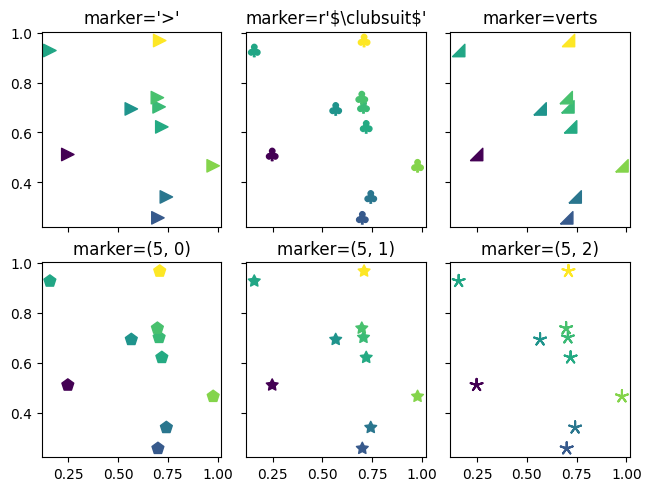

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Fixing random state for reproducibility
np.random.seed(19680801)

x = np.random.rand(10)
y = np.random.rand(10)
z = np.sqrt(x**2 + y**2)

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, layout="constrained")

# Matplotlib marker symbol
axs[0, 0].scatter(x, y, s=80, c=z, marker=">")
axs[0, 0].set_title("marker='>'")

# marker from TeX: passing a TeX symbol name enclosed in $-signs
axs[0, 1].scatter(x, y, s=80, c=z, marker=r"$\clubsuit$")
axs[0, 1].set_title(r"marker=r'\$\clubsuit\$'")

# marker from path: passing a custom path of N vertices as a (N, 2) array-like
verts = [[-1, -1], [1, -1], [1, 1], [-1, -1]]
axs[0, 2].scatter(x, y, s=80, c=z, marker=verts)
axs[0, 2].set_title("marker=verts")

# regular pentagon marker
axs[1, 0].scatter(x, y, s=80, c=z, marker=(5, 0))
axs[1, 0].set_title("marker=(5, 0)")

# regular 5-pointed star marker
axs[1, 1].scatter(x, y, s=80, c=z, marker=(5, 1))
axs[1, 1].set_title("marker=(5, 1)")

# regular 5-pointed asterisk marker
axs[1, 2].scatter(x, y, s=80, c=z, marker=(5, 2))
axs[1, 2].set_title("marker=(5, 2)")

plt.show()

## 2. fill_between with transparency

The fill_between function generates a shaded region between a min and max boundary that is useful for illustrating ranges. It has a very handy where argument to combine filling with logical ranges, e.g., to just fill in a curve over some threshold value.

At its most basic level, fill_between can be used to enhance a graph's visual appearance. Let's compare two graphs of financial data with a simple line plot on the left and a filled line on the right.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.cbook as cbook

# load up some sample financial data
r = cbook.get_sample_data('goog.npz')['price_data']
# create two subplots with the shared x and y axes
fig, (ax1, ax2) = plt.subplots(1, 2, sharex=True, sharey=True)

pricemin = r["close"].min()

ax1.plot(r["date"], r["close"], lw=2)
ax2.fill_between(r["date"], pricemin, r["close"], alpha=0.7)

for ax in ax1, ax2:
    ax.grid(True)
    ax.label_outer()

ax1.set_ylabel('price')

fig.suptitle('Google (GOOG) daily closing price')
fig.autofmt_xdate()

## 3. Grouped bar chart with labels

This example shows a how to create a grouped bar chart and how to annotate bars with labels.

In [ ]:
# data from https://allisonhorst.github.io/palmerpenguins/

import matplotlib.pyplot as plt
import numpy as np

species = ("Adelie", "Chinstrap", "Gentoo")
penguin_means = {
    'Bill Depth': (18.35, 18.43, 14.98),
    'Bill Length': (38.79, 48.83, 47.50),
    'Flipper Length': (189.95, 195.82, 217.19),
}

x = np.arange(len(species))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in penguin_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Penguin attributes by species')
ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 250)

plt.show()